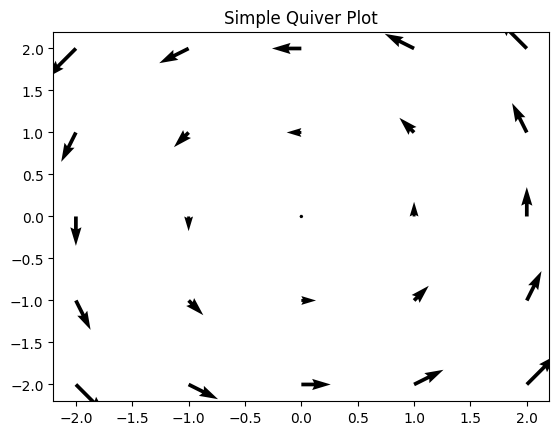

In [1]:
#my try

import matplotlib.pyplot as plt
import numpy as np

# Create grid
x, y = np.meshgrid(np.arange(-2, 3), np.arange(-2, 3))

# Define vector components
u = -y
v = x

# Create quiver plot
plt.quiver(x, y, u, v)

plt.title("Simple Quiver Plot")
plt.show()

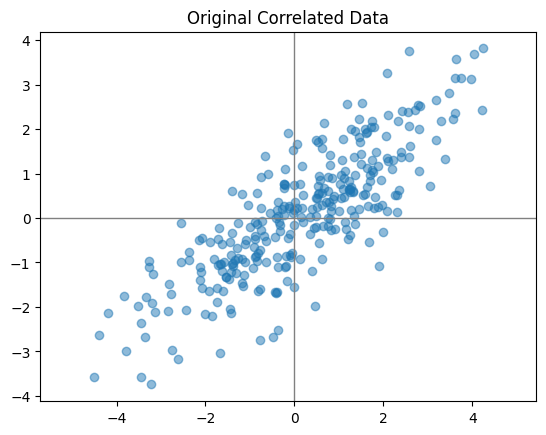

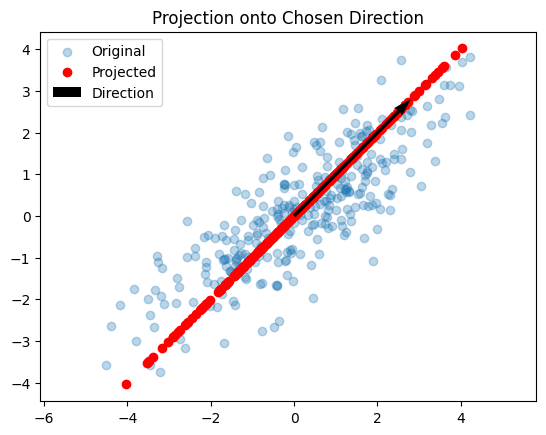

Total variance: 5.095215271365926
Variance along v: 4.596762639116672
Best angle (radians): 0.6663984416705622


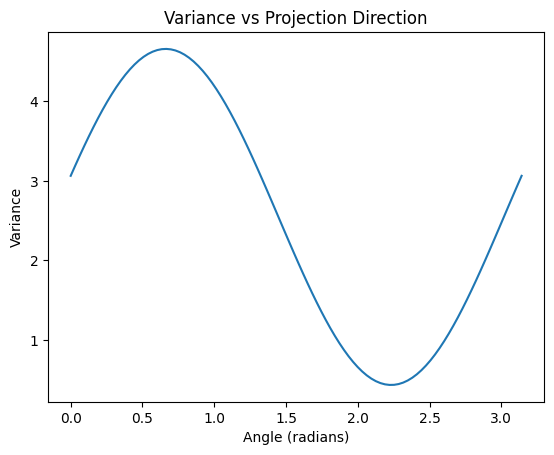

In [2]:
##Assignment 1: Geometry of PCA  

#Generate 2D Correlated Data
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Mean
mean = [0, 0]

# Covariance matrix (introduces correlation)
cov = [[3, 2],
       [2, 2]]

# Generate data
X = np.random.multivariate_normal(mean, cov, 300)

#Plot Original Data
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)
plt.title("Original Correlated Data")
plt.axis('equal')
plt.show()

# Try different directions
v = np.array([1, 1])
v = v / np.linalg.norm(v)  # normalize

# Project data
projections = X @ v          # scalar projection
X_proj = np.outer(projections, v)  # back to 2D

#Plot
plt.scatter(X[:, 0], X[:, 1], alpha=0.3, label="Original")
plt.scatter(X_proj[:, 0], X_proj[:, 1], color='red', label="Projected")

# draw direction vector
plt.quiver(0, 0, v[0], v[1], scale=3, color='black', label="Direction")

plt.legend()
plt.title("Projection onto Chosen Direction")
plt.axis('equal')
plt.show()

#Compare Variance
total_variance = np.var(X, axis=0).sum()
projected_variance = np.var(projections)

print("Total variance:", total_variance)
print("Variance along v:", projected_variance)

#direction preserves max variance
angles = np.linspace(0, np.pi, 100)
variances = []

for theta in angles:
    v = np.array([np.cos(theta), np.sin(theta)])
    proj = X @ v
    variances.append(np.var(proj))

best_angle = angles[np.argmax(variances)]
print("Best angle (radians):", best_angle)

plt.plot(angles, variances)
plt.title("Variance vs Projection Direction")
plt.xlabel("Angle (radians)")
plt.ylabel("Variance")
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15240\3052766600.py:14: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal(mean, cov, 300)


[[4.02028917 2.6771098 ]
 [2.6771098  2.0281446 ]]
Eigenvalues: [5.88062666 0.1678071 ]
Eigenvectors:
 [[ 0.82119266 -0.57065104]
 [ 0.57065104  0.82119266]]
Eigenvalue 0: 5.8806
Variance along eigenvector 0: 5.8610

Eigenvalue 1: 0.1678
Variance along eigenvector 1: 0.1672

Principal direction: [0.82119266 0.57065104]


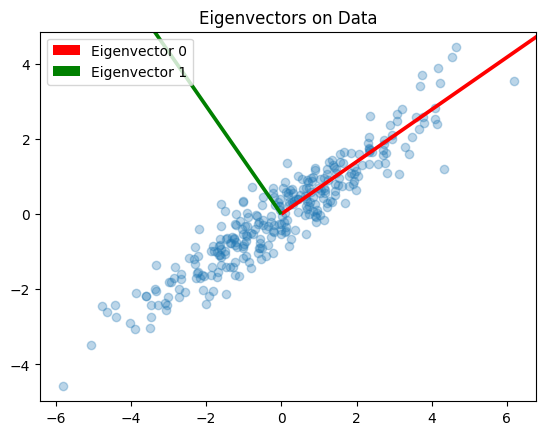

In [1]:
##Assignment 2: Eigenvalues = Variance

#Create 2D dataset

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

mean = [0, 0]
cov = [[4, 3],
       [3, 2]]   # strong correlation

X = np.random.multivariate_normal(mean, cov, 300)

#Center the data
X_centered = X - np.mean(X, axis=0)

#Compute Covariance matrix

cov_matrix = np.cov(X_centered, rowvar=False)
print(cov_matrix)

#Eigen values , Eigen vectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

#Verify: eigenvalue = variance along eigenvector
for i in range(2):
    v = eigenvectors[:, i]          # eigenvector
    projections = X_centered @ v    # project data
    var = np.var(projections)
    
    print(f"Eigenvalue {i}: {eigenvalues[i]:.4f}")
    print(f"Variance along eigenvector {i}: {var:.4f}")
    print()


#Identify direction of max variance
max_index = np.argmax(eigenvalues)

principal_vector = eigenvectors[:, max_index]
print("Principal direction:", principal_vector)

#Plot data and eigen vectors
plt.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.3)

# origin
origin = [0, 0]

# scale vectors for visibility
scale = 3

for i in range(2):
    v = eigenvectors[:, i]
    plt.quiver(*origin, v[0], v[1], 
               scale=1/scale, color=['red','green'][i],
               label=f"Eigenvector {i}")

plt.legend()
plt.title("Eigenvectors on Data")
plt.axis('equal')
plt.show()

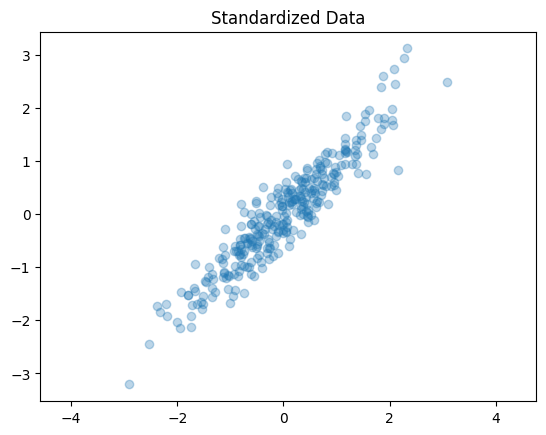

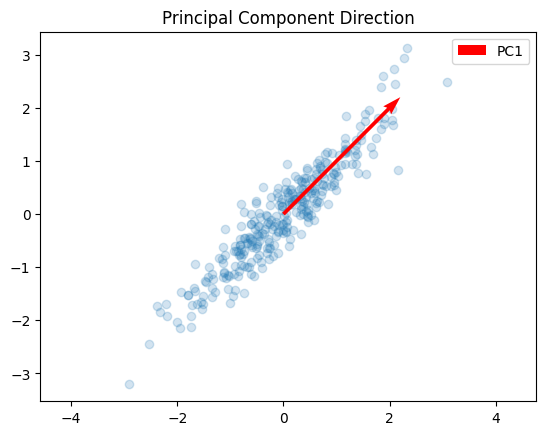

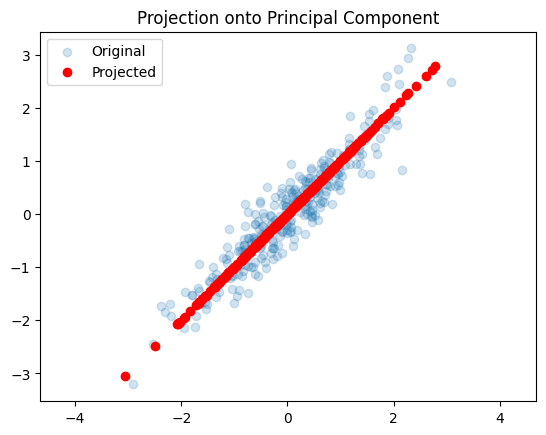

In [2]:
#Assignment 3: Build PCA Step-by-Step  

# mean and std
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

# standardization
X_std = (X - mean) / std

# Compute covariance matrix
cov_matrix = np.cov(X_std, rowvar=False)

# Compute eigen values and eigen vectors

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigen vectors

# sort indices in descending order
sorted_idx = np.argsort(eigenvalues)[::-1]

# reorder
eigenvalues = eigenvalues[sorted_idx]
eigenvectors = eigenvectors[:, sorted_idx]

# Select top K components
k = 1   # reduce to 1D

W = eigenvectors[:, :k]

#Project Data
X_pca = X_std @ W

plt.scatter(X_std[:, 0], X_std[:, 1], alpha=0.3)
plt.title("Standardized Data")
plt.axis('equal')
plt.show()

#Principal Componentr Direction

plt.scatter(X_std[:, 0], X_std[:, 1], alpha=0.2)

# plot principal vector
v = W[:, 0]
plt.quiver(0, 0, v[0], v[1], scale=3, color='red', label="PC1")

plt.legend()
plt.title("Principal Component Direction")
plt.axis('equal')
plt.show()

# reconstruct projection in 2D for visualization
X_proj = (X_std @ W) @ W.T

plt.scatter(X_std[:, 0], X_std[:, 1], alpha=0.2, label="Original")
plt.scatter(X_proj[:, 0], X_proj[:, 1], color='red', label="Projected")

plt.legend()
plt.title("Projection onto Principal Component")
plt.axis('equal')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15240\423204910.py:13: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal(mean, cov, 300)


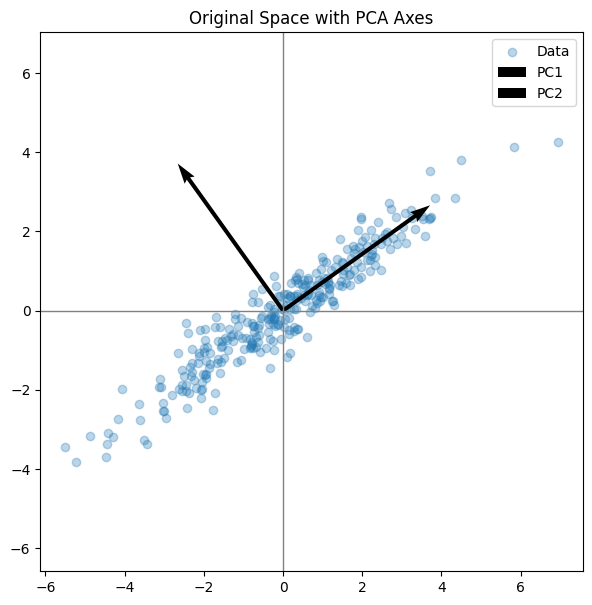

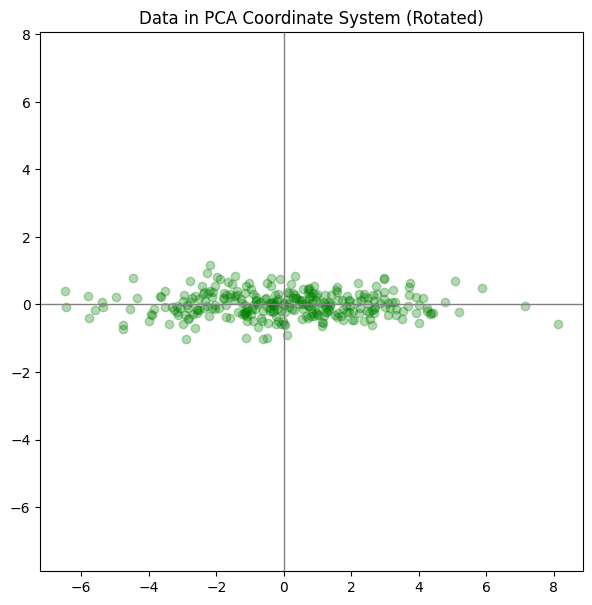

In [3]:
#Assignment 4: Visual Understanding of PCA Rotation

#2D data correlated
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(10)

mean = [0, 0]
cov = [[4, 3],
       [3, 2]]

X = np.random.multivariate_normal(mean, cov, 300)

#Center the data
X_centered = X - np.mean(X, axis=0)

#Compute PCA manually
cov_matrix = np.cov(X_centered, rowvar=False)

eigvals, eigvecs = np.linalg.eig(cov_matrix)

# sort by importance
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

#Rotate data into PCA coordinate
X_pca = X_centered @ eigvecs

plt.figure(figsize=(7,7))

# scatter plot
plt.scatter(X_centered[:,0], X_centered[:,1], alpha=0.3, label="Data")

# original axes
plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

# PCA axes (eigenvectors)
origin = np.array([0, 0])

for i in range(2):
    vec = eigvecs[:, i]
    plt.quiver(*origin, vec[0], vec[1],
               scale=3,
               label=f"PC{i+1}")

plt.title("Original Space with PCA Axes")
plt.axis('equal')
plt.legend()
plt.show()

#Plot rotated PCA space
plt.figure(figsize=(7,7))

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.3, color='green')

plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

plt.title("Data in PCA Coordinate System (Rotated)")
plt.axis('equal')
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_15240\4060287151.py:13: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  X = np.random.multivariate_normal(mean, cov, 300)


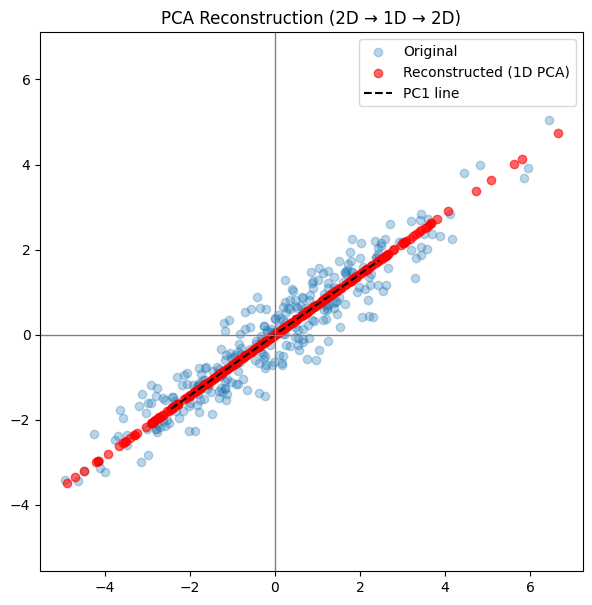

In [4]:
#Assignment 5: Reconstruction Error

#Generate dataset
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(5)

mean = [0, 0]
cov = [[4, 3],
       [3, 2]]

X = np.random.multivariate_normal(mean, cov, 300)

#Center the data
X_centered = X - np.mean(X, axis=0)

#Compute PCA directions (eigenvectors)
cov_matrix = np.cov(X_centered, rowvar=False)

eigvals, eigvecs = np.linalg.eig(cov_matrix)

# sort 
idx = np.argsort(eigvals)[::-1]
eigvecs = eigvecs[:, idx]

#Reduce 2D → 1D

#We keep only the first principal component:

W = eigvecs[:, :1]   # shape (2,1)

X_1d = X_centered @ W   # projection onto PC1



#Reconstruct back to 2D

#We map it back:

X_reconstructed = X_1d @ W.T



#Plot original vs reconstructed
plt.figure(figsize=(7,7))

# original data
plt.scatter(X_centered[:,0], X_centered[:,1],
            alpha=0.3, label="Original")

# reconstructed data
plt.scatter(X_reconstructed[:,0], X_reconstructed[:,1],
            color='red', alpha=0.6, label="Reconstructed (1D PCA)")

# PCA direction line
v = W[:,0]
line = np.linspace(-3, 3, 100)
plt.plot(line * v[0], line * v[1], color='black', linestyle='--', label="PC1 line")

plt.axhline(0, color='gray', linewidth=1)
plt.axvline(0, color='gray', linewidth=1)

plt.legend()
plt.title("PCA Reconstruction (2D → 1D → 2D)")
plt.axis('equal')
plt.show()

PC1 (no scaling): [-0.08160824 -0.99666448]


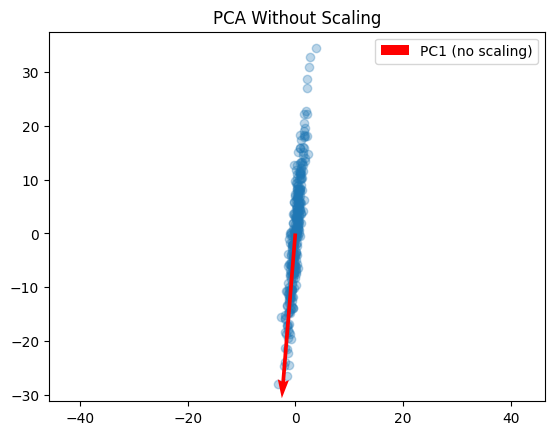

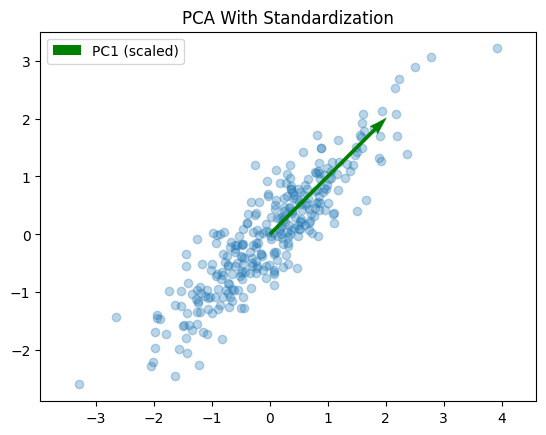

PC1 without scaling: [-0.08160824 -0.99666448]
PC1 with scaling: [0.70710678 0.70710678]


In [5]:
#Assignment 6: Effect of Scaling  

#Create dataset with different scales

#We intentionally make one feature much larger than the other.

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 300

# Feature 1: small scale
x1 = np.random.normal(0, 1, n)

# Feature 2: large scale (10x bigger)
x2 = 10 * x1 + np.random.normal(0, 5, n)

X = np.column_stack([x1, x2])

# PCA WITHOUT scaling
#Step 1: covariance matrix
cov = np.cov(X, rowvar=False)

eigvals, eigvecs = np.linalg.eig(cov)

idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

#Principal component direction
pc1_no_scale = eigvecs[:, 0]
print("PC1 (no scaling):", pc1_no_scale)
#Plot
plt.scatter(X[:,0], X[:,1], alpha=0.3)

plt.quiver(0, 0, pc1_no_scale[0], pc1_no_scale[1],
           scale=3, color='red', label="PC1 (no scaling)")

plt.title("PCA Without Scaling")
plt.axis('equal')
plt.legend()
plt.show()

# PCA WITH standardization
#Step 1: standardize
X_std = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

#Step 2: covariance + PCA
cov_std = np.cov(X_std, rowvar=False)

eigvals_s, eigvecs_s = np.linalg.eig(cov_std)

idx = np.argsort(eigvals_s)[::-1]
eigvals_s = eigvals_s[idx]
eigvecs_s = eigvecs_s[:, idx]

pc1_scale = eigvecs_s[:, 0]
#Plot
plt.scatter(X_std[:,0], X_std[:,1], alpha=0.3)

plt.quiver(0, 0, pc1_scale[0], pc1_scale[1],
           scale=3, color='green', label="PC1 (scaled)")

plt.title("PCA With Standardization")
plt.axis('equal')
plt.legend()
plt.show()

#Compare results
print("PC1 without scaling:", pc1_no_scale)
print("PC1 with scaling:", pc1_scale)

In [6]:
#Assignment 7: Variance Explained  

#Create dataset
import numpy as np

np.random.seed(0)

mean = [0, 0]
cov = [[5, 3],
       [3, 2]]

X = np.random.multivariate_normal(mean, cov, 300)

# Center data
X_centered = X - np.mean(X, axis=0)

#Compute covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

#Eigen decomposition (PCA from scratch)
eigvals, eigvecs = np.linalg.eig(cov_matrix)

# sort in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Explained Variance Ratio (manual)

explained_variance_ratio_manual = eigvals / np.sum(eigvals)

print("Eigenvalues:", eigvals)
print("Explained Variance Ratio (manual):", explained_variance_ratio_manual)

#Each eigenvalue = variance along that direction.


# PCA using sklearn (for verification)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(X)

#sklearn explained variance
print("Sklearn eigenvalues:", pca.explained_variance_)
print("Sklearn explained variance ratio:", pca.explained_variance_ratio_)

#Compare results
print("\nManual vs Sklearn comparison:")
print("Manual:", explained_variance_ratio_manual)
print("Sklearn:", pca.explained_variance_ratio_)




Eigenvalues: [7.02693679 0.14497533]
Explained Variance Ratio (manual): [0.97978568 0.02021432]
Sklearn eigenvalues: [7.02693679 0.14497533]
Sklearn explained variance ratio: [0.97978568 0.02021432]

Manual vs Sklearn comparison:
Manual: [0.97978568 0.02021432]
Sklearn: [0.97978568 0.02021432]


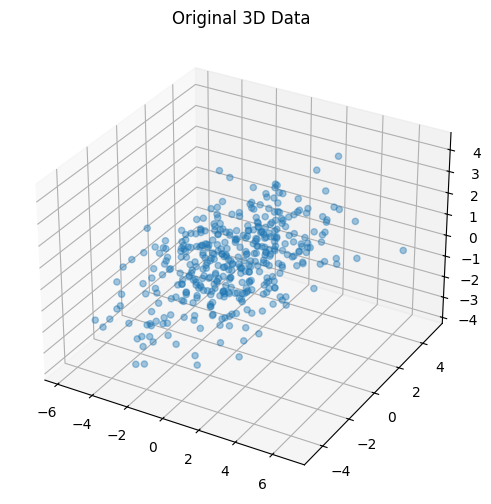

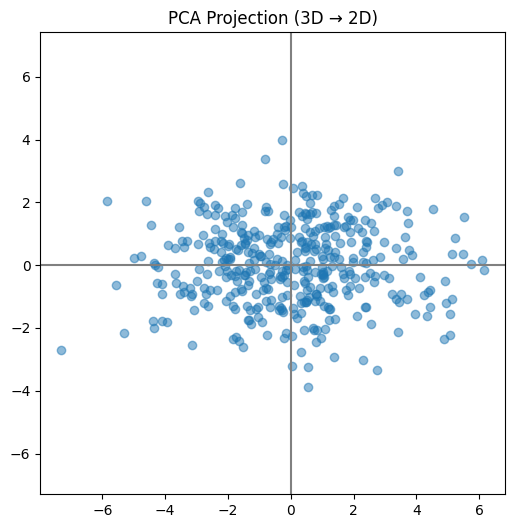

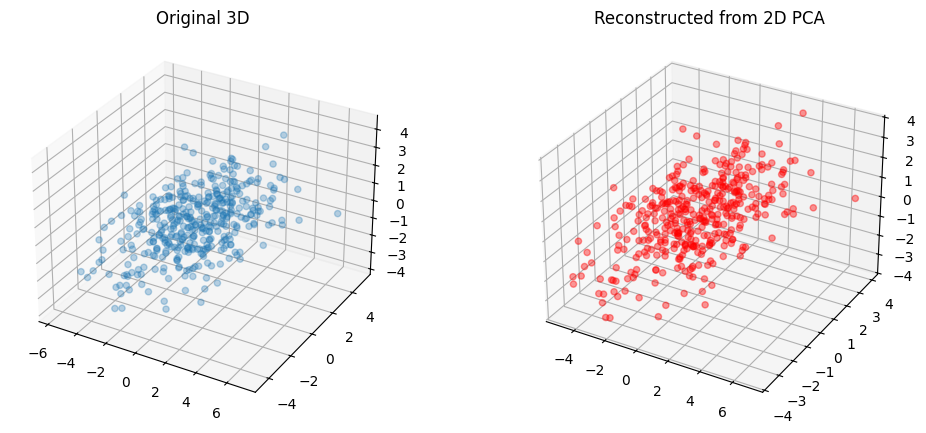

In [7]:
#Assignment 8: PCA on 3D Data  

#Create 3D dataset

#We generate correlated 3D data so PCA has something meaningful to find.

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

mean = [0, 0, 0]

cov = [[4, 2, 1],
       [2, 3, 1],
       [1, 1, 2]]

X = np.random.multivariate_normal(mean, cov, 400)

#3D visualization
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:,0], X[:,1], X[:,2], alpha=0.4)

ax.set_title("Original 3D Data")
plt.show()

#Center the data
X_centered = X - np.mean(X, axis=0)

#Covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

# Eigen decomposition (PCA)
eigvals, eigvecs = np.linalg.eig(cov_matrix)

# sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Reduce 3D → 2D

#We keep top 2 principal components:

W = eigvecs[:, :2]   # projection matrix (3 × 2)

X_pca = X_centered @ W


# 2D projection visualization
plt.figure(figsize=(6,6))

plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)

plt.axhline(0, color='gray')
plt.axvline(0, color='gray')

plt.title("PCA Projection (3D → 2D)")
plt.axis('equal')
plt.show()

#show reconstructed 3D points

X_reconstructed = X_pca @ W.T

# Compare original vs reconstructed (3D)
fig = plt.figure(figsize=(12,5))

# original
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X_centered[:,0], X_centered[:,1], X_centered[:,2], alpha=0.3)
ax1.set_title("Original 3D")

# reconstructed
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X_reconstructed[:,0], X_reconstructed[:,1], X_reconstructed[:,2],
            color='red', alpha=0.4)
ax2.set_title("Reconstructed from 2D PCA")

plt.show()

Original size (bytes): 12000
Reduced size (bytes): 8000
Compression ratio: 1.5
Reconstruction Error (MSE): 0.007462954661306851


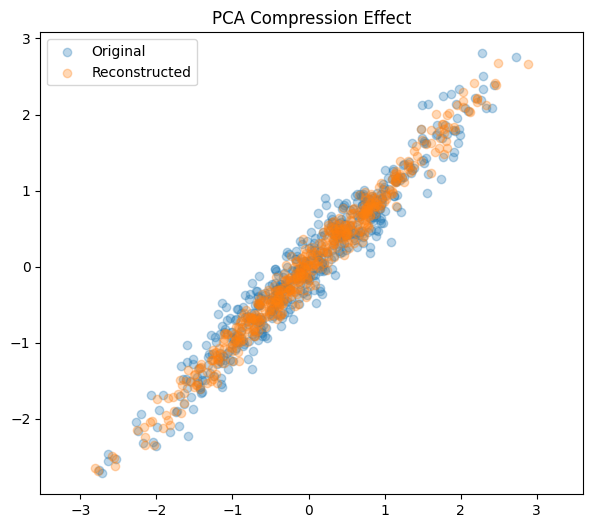

In [8]:
#Assignment 9: PCA as Compression

#Create dataset

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

n = 500

# 3 correlated features
x1 = np.random.normal(0, 1, n)
x2 = 2 * x1 + np.random.normal(0, 0.5, n)
x3 = -x1 + np.random.normal(0, 0.3, n)

X = np.column_stack([x1, x2, x3])


# Standardize data
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)

X_scaled = (X - X_mean) / X_std

# PCA from scratch
# covariance
cov = np.cov(X_scaled, rowvar=False)

# eigen decomposition
eigvals, eigvecs = np.linalg.eig(cov)

# sort
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

#Reduce dimensions (3D → 2D)
k = 2  # compression level

W = eigvecs[:, :k]

X_reduced = X_scaled @ W

# Compare sizes (compression effect)
original_size = X_scaled.nbytes
reduced_size = X_reduced.nbytes

print("Original size (bytes):", original_size)
print("Reduced size (bytes):", reduced_size)
print("Compression ratio:", original_size / reduced_size)

# Reconstruct data
X_reconstructed = X_reduced @ W.T

# Compute reconstruction error

#We use Mean Squared Error (MSE):

mse = np.mean((X_scaled - X_reconstructed) ** 2)

print("Reconstruction Error (MSE):", mse)

#Visual comparison (original vs reconstructed)

#We compare first two dimensions visually.

plt.figure(figsize=(7,6))

plt.scatter(X_scaled[:,0], X_scaled[:,1],
            alpha=0.3, label="Original")

plt.scatter(X_reconstructed[:,0], X_reconstructed[:,1],
            alpha=0.3, label="Reconstructed")

plt.title("PCA Compression Effect")
plt.legend()
plt.axis('equal')
plt.show()

In [ ]:
What does PCA optimize mathematically?

It finds directions (vectors) that maximize the variance of the projected data.

PCA finds the best low-dimensional representation of data by keeping directions with maximum variance and minimum information loss

In [ ]:
Why is variance used as a measure of “information”? 

Variance is used as “information” because it captures how much a feature helps distinguish data points, which is exactly what PCA tries to preserve.

In [ ]:
•	What happens if features are not correlated — is PCA useful? 
If features are uncorrelated, PCA mostly does nothing new—it won’t significantly reduce dimensionality or reveal hidden structure.

In [ ]:
•	Why do we standardize data before applying PCA? 
If you skip standardization before PCA, you’re basically telling the algorithm: “give more importance to features with larger numeric scales”—which is usually not what you want.

In [ ]:
•	What is the difference between covariance and correlation in PCA context? 

Covariance → measures how two features vary together (depends on scale)
Correlation → measures how strongly they are related (scale-independent, normalized)

In [ ]:
•	How is PCA related to projection of data onto a new axis? 
PCA finds axes such that:

1st axis → direction of maximum variance
2nd axis → next highest variance (perpendicular)
and so on



In [ ]:
•	Why are principal components orthogonal to each other? 
PCA computes eigenvectors of the covariance matrix.

The covariance matrix is symmetric
Eigenvectors of a symmetric matrix are orthogonal

That’s why principal components automatically come out perpendicular

In [ ]:
•	What does it mean to “rotate the coordinate system” in PCA? 

Rotating the coordinate system” in PCA is as follows:

We change the axes (basis) we use to describe the data, without moving the data itself

In [ ]:
•	How does PCA reduce redundancy in features? 

PCA reduces redundancy by detecting and combining correlated features into fewer, independent components.

In [ ]:
•	Can principal components always be interpreted easily? Why or why not? 
No, principal components are often not easy to interpret
Because of 
High dimensional data
Linear combination of features
Mixing unrelated features
Sign and scale 


In [ ]:
•	What does a negative loading in a principal component indicate? 
A negative loading in a principal component simply means that the original feature varies in the opposite direction of that component.

In [ ]:
•	What does it mean if the first principal component explains 90% variance? 
If the first principal component explains 90% of the variance, it means:
 Almost all the structure (spread/information) in your data lies along one direction.

In [ ]:
•	If two features are highly correlated, how will PCA treat them? 
If two features are highly correlated, PCA treats them as redundant information and typically combines them into a single principal component.

In [ ]:
•	Does PCA use output labels? What is the implication? 
No PCA doesnot use output labels
Doesnot care about prediction task
Important information for prediction may be lost as part of PCA

In [ ]:
•	When should PCA be avoided even if dimensionality is high? 

PCA should be avoided when interpretability, label-relevant low-variance signals, sparsity, or nonlinear structure are important, or when modern models already handle high-dimensional data well.

In [ ]:
•	How does PCA affect model interpretability? 

PCA improves efficiency and reduces redundancy but hurts interpretability because it replaces meaningful features with abstract combinations of them.


In [ ]:
•	Can PCA improve model performance always? Why not? 

PCA does not always improve model performance because it preserves variance, not predictive relevance, and may discard low-variance but important features.
    

In [ ]:
•	What happens if all features have equal variance and no correlation? 

If all features have equal variance and no correlation, PCA becomes essentially uninformative for dimensionality reduction.

In [ ]:
•	What if one feature has extremely large scale compared to others? 

If one feature has an extremely large scale compared to others, PCA becomes heavily biased toward that feature unless you standardize the data first.

In [ ]:
•	Can PCA capture nonlinear relationships? Why or why not? 

PCA cannot capture nonlinear relationships because it is strictly a linear projection method that only rotates and projects data along straight axes.

In [ ]:
•	Why might PCA fail in classification problems? 

PCA can fail in classification because it is not designed to separate classes, it is designed to preserve variance in the input data.
    Thats where LDA comes into play.